# **Aprendizado de Máquina**<BR> **Aula 02** - Modelos de regressão linear e não linear

# **Exemplo 1**: regressão linear <u>múltipla</u> com dados externos (arquivo .CSV)

## **1)** Importação de bibliotecas e classes

In [ ]:
import pandas as pd                   # Leitura de dados e operações em DataFrames
from matplotlib import pyplot as plt  # Geração de gráficos
import numpy as np

from sklearn.linear_model import LinearRegression   # Regressão linear

## **2)** Leitura de dados e exploração inicial

In [ ]:
# Antes de executar essa célula é preciso
# 1) "Montar" o disco
# 2) Ajustar o caminho do arquivo

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/A02EXEMPLO1.csv')
df.head()
#display(df)

,x1,x2,y
0,1.188,40.91,8.9
1,1.304,42.30,8.9
2,1.052,46.25,9.7
3,1.458,48.32,9.1
4,1.560,42.30,8.0


### **2.1)** Características gerais

In [ ]:
# Dimensões do DataFrame
df.shape


(32, 3)

In [ ]:
# Nomes das colunas
df.columns

Index(['x1', 'x2', 'y'], dtype='object')

In [ ]:
# Tipos de dados das variáveis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      32 non-null     float64
 1   x2      32 non-null     float64
 2   y       32 non-null     float64
dtypes: float64(3)
memory usage: 900.0 bytes


In [ ]:
# Resumo estatístico
df.describe()

,x1,x2,y
count,32.000000,32.000000,32.000000
mean,1.459219,44.362812,8.550000
std,0.443746,4.441415,2.558477
min,0.686000,36.040000,4.400000
25%,1.170500,41.982500,6.575000
50%,1.508000,44.015000,8.200000
75%,1.637250,46.980000,9.700000
max,2.460000,56.920000,14.400000


### **2.2)** Gráficos

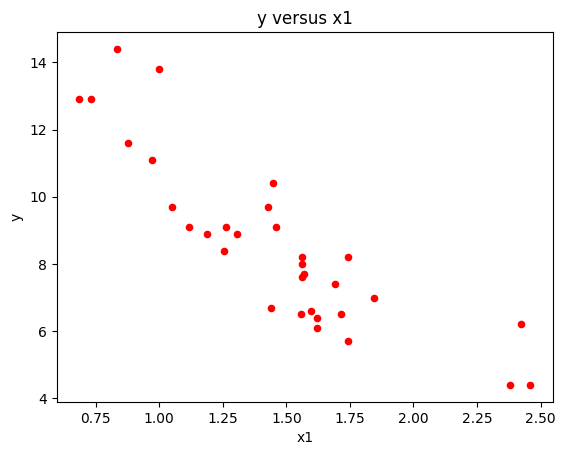

In [ ]:
# Diagrama de dispersão entre y e x1
df.plot.scatter(x = 'x1',y = 'y',c = 'red')
plt.title("y versus x1")
plt.xlabel("x1")
plt.ylabel("y")
plt.show()

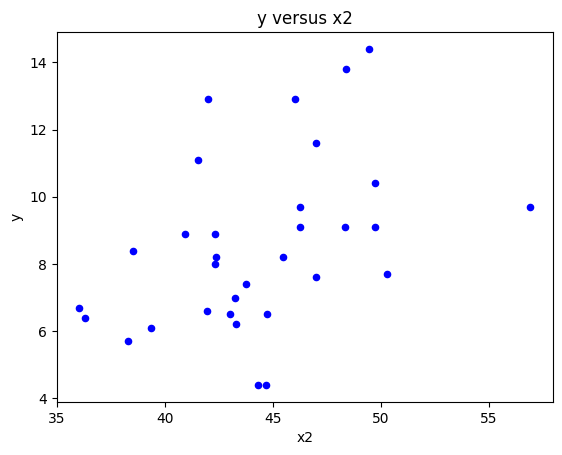

In [ ]:
# Diagrama de dispersão entre y e x1
df.plot.scatter(x = 'x2',y = 'y',c = 'blue')
plt.title("y versus x2")
plt.xlabel("x2")
plt.ylabel("y")
plt.show()

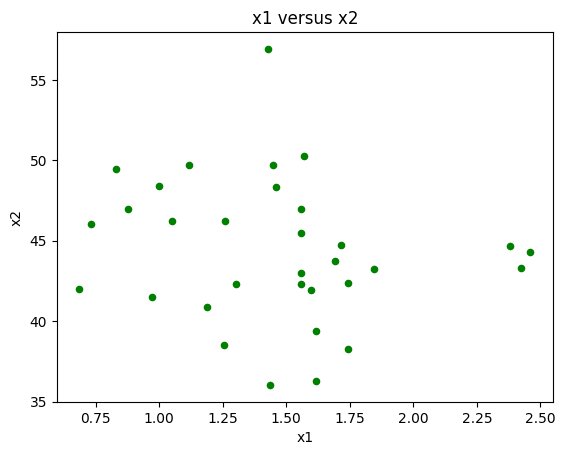

In [ ]:
# Diagrama de dispersão entre y e x1
df.plot.scatter(x = 'x1',y = 'x2',c = 'green')
plt.title("x1 versus x2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

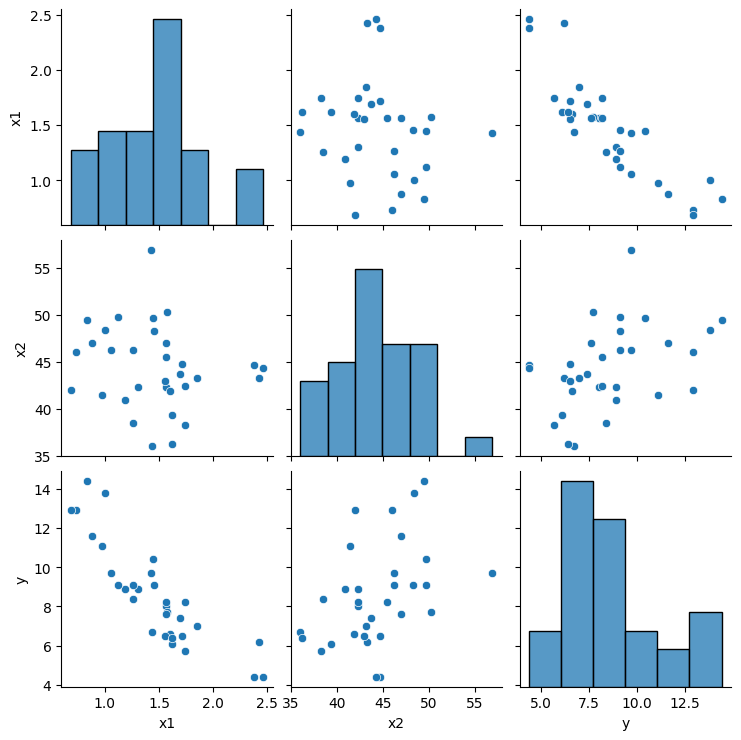

In [ ]:
# Visualização "melhorada" dos diagramas de dispersão: biblioteca Seaborn!
# Importaçao da biblioteca e geração da matriz de diagramas de dispersão

import seaborn as sns
sns.pairplot(df)
plt.show()

### **2.3)** Correlações

In [ ]:
# Análise das correlações lineares
# Critério: |r| entre 0 e 0,4: fraca
#           |r| acima de 0,4 e abaixo de 0,7: moderada
#           |r| maior ou igual a 0,7: forte
df.corr()

,x1,x2,y
x1,1.000000,-0.174542,-0.868379
x2,-0.174542,1.000000,0.417581
y,-0.868379,0.417581,1.000000


## **3)** Seleção de variáveis

In [ ]:
y = df['y']
X = df[['x1', 'x2']]


In [ ]:
# Exibir a variável dependente (y)
display(y)

,y
0,8.9
1,8.9
2,9.7
3,9.1
4,8.0
5,7.7
6,6.1
7,10.4
8,9.7
9,8.2


In [ ]:
# Exibir as variáveis independentes
display(X)

,x1,x2
0,1.188,40.91
1,1.304,42.30
2,1.052,46.25
3,1.458,48.32
4,1.560,42.30
5,1.569,50.26
6,1.619,39.37
7,1.447,49.71
8,1.429,56.92
9,1.560,45.48


## **4)** Treinamento do modelo (regressão linear múltipla)

In [ ]:
# Forma do modelo: y^ = f(x1,x2) = theta_0 + theta_1*x1 + theta_2*x2

reg2 = LinearRegression() # Cria objeto de modelo liniar
reg2.fit(X,y)             # Treina o modelo usando todos os dados


LinearRegression()

## **5)** Exibição dos coeficientes do modelo e da qualidade do ajuste

In [ ]:
# Coeficientes
print('theta_0 = ', reg2.intercept_)
print('theta_1 = ', reg2.coef_[0])
print('theta_2 = ', reg2.coef_[1])


theta_0 =  8.441435076982657
theta_1 =  -4.730646138560884
theta_2 =  0.15805157682508256


In [ ]:
# Função para o cálculo do coeficiente de determinação da regressão
# linear simples (R^2) ou múltipla (R^2 ajustado):

def R2_R2ajust(regressor,X,y):
  R2 = regressor.score(X,y)  # R^2
  n = len(y)      # Quantidade de dados de treino
  m = X.shape[1]  # Quantidade de variáveis independentes do modelo
  if m == 1:
    return R2   # Regressão simples: retorna R^2
  else:
    return 1-((n-1)/(n-m-1))*(1-R2)  # Regressão múltipla: R^2 ajustado

In [ ]:
# Qualidade do ajuste
print('R^2 = ', R2_R2ajust(reg2,X,y))

R^2 =  0.815141740907082


## **6)** Previsão pontual

In [ ]:
# Dados de previsão: x1 = 2, x2 = 50
# Cria dicionário de preovisão
X_prev = {'x1': [2], 'x2': [50]}

# Converte o dicionário em dataFrame
X_prev = pd.DataFrame(X_prev)

# Exibe o dataFrame
display(X_prev)

,x1,x2
0,2,50


In [ ]:
# Previsão = y^(2,50)
y_prev = reg2.predict(X_prev)
print('y_prev = ', round(y_prev[0], 3))

y_prev =  6.883


---
**Fim do Exemplo 1 da Aula 02**